In [1]:
import pandas as pd
import numpy as np

# DATASET: GERMAN CREDIT RISK

In [2]:
pd.set_option('display.float_format', '{:.10f}'.format)

In [3]:
reducao_codecarbon = pd.read_csv('/content/drive/MyDrive/Pesquisa 2/Código/german_credit_data/[REDUÇÃO - CODECARBON]resultados_experimentos[german_credit_data].csv', sep=';')
aumento_codecarbon = pd.read_csv('/content/drive/MyDrive/Pesquisa 2/Código/german_credit_data/[AUMENTO - CODECARBON]resultados_experimentos[german_credit_data].csv', sep=';')

reducao_eco2ai = pd.read_csv('/content/drive/MyDrive/Pesquisa 2/Código/german_credit_data/eco2ai/[REDUÇÃO - ECO2AI]resultados_experimentos[german_credit_data].csv', sep=';')
aumento_eco2ai = pd.read_csv('/content/drive/MyDrive/Pesquisa 2/Código/german_credit_data/eco2ai/[AUMENTO - ECO2AI]resultados_experimentos[german_credit_data].csv', sep=';')

reducao_carbontracker = pd.read_csv('/content/drive/MyDrive/Pesquisa 2/Código/german_credit_data/carbontracker/[REDUCAO - CARBONTRACKER]german_credit_data.csv', sep=';')
aumento_carbontracker = pd.read_csv('/content/drive/MyDrive/Pesquisa 2/Código/german_credit_data/carbontracker/[AUMENTO - CARBONTRACKER]german_credit_data.csv', sep=';')

In [4]:
reducao_codecarbon = reducao_codecarbon.rename(columns={
    "Redução": "Reducao",
    "Acurácia": "Acuracia",
    "Precisão": "Precisao",
    "Emissões (gCO₂eq)": "Emissoes (g)"
})

aumento_codecarbon = aumento_codecarbon.rename(columns={
    "Redução": "Aumento",
    "Acurácia": "Acuracia",
    "Precisão": "Precisao",
    "Emissões (gCO₂eq)": "Emissoes (g)"
})

reducao_eco2ai = reducao_eco2ai.rename(columns={
    "Redução": "Reducao",
    "Acurácia": "Acuracia",
    "Precisão": "Precisao",
    "Emissões (kg)": "Emissoes (g)",
    "Tempo medido (s)": "Tempo (s)"
})

aumento_eco2ai = aumento_eco2ai.rename(columns={
    "Acurácia": "Acuracia",
    "Precisão": "Precisao",
    "Emissões (kg)": "Emissoes (g)",
    "Tempo medido (s)": "Tempo (s)"
})

reducao_carbontracker = reducao_carbontracker.rename(columns={
    "RGA (kg/ac)": "RGA",
    "Alteracao": "Reducao"
})

aumento_carbontracker = aumento_carbontracker.rename(columns={
    "RGA (kg/ac)": "RGA",
    "Alteracao": "Reducao"
})

In [ ]:
total_co2_emissions = (
    reducao_carbontracker['Emissoes (g)'].sum() +
    aumento_carbontracker['Emissoes (g)'].sum() +
    reducao_codecarbon['Emissoes (g)'].sum() +
    aumento_codecarbon['Emissoes (g)'].sum()
)

total_energia = (
    reducao_carbontracker['Energia (kWh)'].sum() +
    aumento_carbontracker['Energia (kWh)'].sum() +
    reducao_codecarbon['Energia (kWh)'].sum() +
    aumento_codecarbon['Energia (kWh)'].sum()
)


print(f"German\nCO2: {total_co2_emissions}\nEnergia: {total_energia}")

### POR MODELO

In [ ]:
#codecarbon RF

rf_raw_codecarbon_melhor = reducao_codecarbon[reducao_codecarbon['Modelo'] == 'RandomForest']
rf_raw_codecarbon_melhor = rf_raw_codecarbon_melhor[rf_raw_codecarbon_melhor['Reducao'] == '-0%']

rf_red_codecarbon_melhor = reducao_codecarbon.loc[[
    reducao_codecarbon[reducao_codecarbon['Modelo'] == 'RandomForest']['RGA'].idxmin()
]]

rf_aumento_codecarbon_melhor = aumento_codecarbon.loc[[aumento_codecarbon[aumento_codecarbon['Modelo'] == 'RandomForest']['RGA'].idxmin()]]

melhores_RF_codecarbon = pd.concat([
    rf_raw_codecarbon_melhor,
    rf_red_codecarbon_melhor,
    rf_aumento_codecarbon_melhor
])


pior_red_codecarbon = reducao_codecarbon.loc[[reducao_codecarbon[reducao_codecarbon['Modelo'] == 'RandomForest']['RGA'].idxmax()]]
pior_aum_codecarbon = aumento_codecarbon.loc[[aumento_codecarbon[aumento_codecarbon['Modelo'] == 'RandomForest']['RGA'].idxmax()]]



piores_RF_codecarbon = pd.concat([
    pior_red_codecarbon,
    pior_aum_codecarbon
])

In [ ]:
#carbontracker RF

rf_raw_carbontracker_melhor = reducao_carbontracker[reducao_carbontracker['Modelo'] == 'RandomForest']
rf_raw_carbontracker_melhor = rf_raw_carbontracker_melhor[rf_raw_carbontracker_melhor['Reducao'] == '-0%']

rf_red_carbontracker_melhor = reducao_carbontracker.loc[[
    reducao_carbontracker[reducao_carbontracker['Modelo'] == 'RandomForest']['RGA'].idxmin()
]]

rf_aumento_carbontracker_melhor = aumento_carbontracker.loc[[aumento_carbontracker[aumento_carbontracker['Modelo'] == 'RandomForest']['RGA'].idxmin()]]

melhores_RF_carbontracker = pd.concat([
    rf_raw_carbontracker_melhor,
    rf_red_carbontracker_melhor,
    rf_aumento_carbontracker_melhor
])


pior_red_carbontracker = reducao_carbontracker.loc[[reducao_carbontracker[reducao_carbontracker['Modelo'] == 'RandomForest']['RGA'].idxmax()]]
pior_aum_carbontracker = aumento_carbontracker.loc[[aumento_carbontracker[aumento_carbontracker['Modelo'] == 'RandomForest']['RGA'].idxmax()]]



piores_RF_carbontracker = pd.concat([
    pior_red_carbontracker,
    pior_aum_carbontracker
])

In [ ]:
#codecarbon LGBM

rf_raw_codecarbon_melhor = reducao_codecarbon[reducao_codecarbon['Modelo'] == 'LightGBM']
rf_raw_codecarbon_melhor = rf_raw_codecarbon_melhor[rf_raw_codecarbon_melhor['Reducao'] == '-0%']

rf_red_codecarbon_melhor = reducao_codecarbon.loc[[
    reducao_codecarbon[reducao_codecarbon['Modelo'] == 'LightGBM']['RGA'].idxmin()
]]

rf_aumento_codecarbon_melhor = aumento_codecarbon.loc[[aumento_codecarbon[aumento_codecarbon['Modelo'] == 'LightGBM']['RGA'].idxmin()]]

melhores_RF_codecarbon = pd.concat([
    rf_raw_codecarbon_melhor,
    rf_red_codecarbon_melhor,
    rf_aumento_codecarbon_melhor
])


pior_red_codecarbon = reducao_codecarbon.loc[[reducao_codecarbon[reducao_codecarbon['Modelo'] == 'LightGBM']['RGA'].idxmax()]]
pior_aum_codecarbon = aumento_codecarbon.loc[[aumento_codecarbon[aumento_codecarbon['Modelo'] == 'LightGBM']['RGA'].idxmax()]]



piores_RF_codecarbon = pd.concat([
    pior_red_codecarbon,
    pior_aum_codecarbon
])

In [ ]:
#carbontracker LGBM

rf_raw_carbontracker_melhor = reducao_carbontracker[reducao_carbontracker['Modelo'] == 'LightGBM']
rf_raw_carbontracker_melhor = rf_raw_carbontracker_melhor[rf_raw_carbontracker_melhor['Reducao'] == '-0%']

rf_red_carbontracker_melhor = reducao_carbontracker.loc[[
    reducao_carbontracker[reducao_carbontracker['Modelo'] == 'LightGBM']['RGA'].idxmin()
]]

rf_aumento_carbontracker_melhor = aumento_carbontracker.loc[[aumento_carbontracker[aumento_carbontracker['Modelo'] == 'LightGBM']['RGA'].idxmin()]]

melhores_RF_carbontracker = pd.concat([
    rf_raw_carbontracker_melhor,
    rf_red_carbontracker_melhor,
    rf_aumento_carbontracker_melhor
])


pior_red_carbontracker = reducao_carbontracker.loc[[reducao_carbontracker[reducao_carbontracker['Modelo'] == 'LightGBM']['RGA'].idxmax()]]
pior_aum_carbontracker = aumento_carbontracker.loc[[aumento_carbontracker[aumento_carbontracker['Modelo'] == 'LightGBM']['RGA'].idxmax()]]



piores_RF_carbontracker = pd.concat([
    pior_red_carbontracker,
    pior_aum_carbontracker
])

In [ ]:
#codecarbon RNA

rf_raw_codecarbon_melhor = reducao_codecarbon[reducao_codecarbon['Modelo'] == 'RNA']
rf_raw_codecarbon_melhor = rf_raw_codecarbon_melhor[rf_raw_codecarbon_melhor['Reducao'] == '-0%']

rf_red_codecarbon_melhor = reducao_codecarbon.loc[[
    reducao_codecarbon[reducao_codecarbon['Modelo'] == 'RNA']['RGA'].idxmin()
]]

rf_aumento_codecarbon_melhor = aumento_codecarbon.loc[[aumento_codecarbon[aumento_codecarbon['Modelo'] == 'RNA']['RGA'].idxmin()]]

melhores_RF_codecarbon = pd.concat([
    rf_raw_codecarbon_melhor,
    rf_red_codecarbon_melhor,
    rf_aumento_codecarbon_melhor
])


pior_red_codecarbon = reducao_codecarbon.loc[[reducao_codecarbon[reducao_codecarbon['Modelo'] == 'RNA']['RGA'].idxmax()]]
pior_aum_codecarbon = aumento_codecarbon.loc[[aumento_codecarbon[aumento_codecarbon['Modelo'] == 'RNA']['RGA'].idxmax()]]



piores_RF_codecarbon = pd.concat([
    pior_red_codecarbon,
    pior_aum_codecarbon
])

In [ ]:
#carbontracker RNA

rf_raw_carbontracker_melhor = reducao_carbontracker[reducao_carbontracker['Modelo'] == 'RNA']
rf_raw_carbontracker_melhor = rf_raw_carbontracker_melhor[rf_raw_carbontracker_melhor['Reducao'] == '-0%']

rf_red_carbontracker_melhor = reducao_carbontracker.loc[[
    reducao_carbontracker[reducao_carbontracker['Modelo'] == 'RNA']['RGA'].idxmin()
]]

rf_aumento_carbontracker_melhor = aumento_carbontracker.loc[[aumento_carbontracker[aumento_carbontracker['Modelo'] == 'RNA']['RGA'].idxmin()]]

melhores_RF_carbontracker = pd.concat([
    rf_raw_carbontracker_melhor,
    rf_red_carbontracker_melhor,
    rf_aumento_carbontracker_melhor
])


pior_red_carbontracker = reducao_carbontracker.loc[[reducao_carbontracker[reducao_carbontracker['Modelo'] == 'RNA']['RGA'].idxmax()]]
pior_aum_carbontracker = aumento_carbontracker.loc[[aumento_carbontracker[aumento_carbontracker['Modelo'] == 'RNA']['RGA'].idxmax()]]



piores_RF_carbontracker = pd.concat([
    pior_red_carbontracker,
    pior_aum_carbontracker
])

In [ ]:
import pandas as pd
import numpy as np

# ===== 1. PADRONIZAÇÃO E UNIFICAÇÃO DE COLUNAS =====
for df in [reducao_codecarbon, reducao_carbontracker]:
    df.rename(columns={'Reducao': 'Strategy (%)', 'Modelo': 'Model', 'Acuracia': 'Accuracy', 'Emissoes (g)': 'CO2_g', 'Tempo (s)': 'Time_s'}, inplace=True)

for df in [aumento_codecarbon, aumento_carbontracker]:
    df.rename(columns={'Aumento': 'Strategy (%)', 'Modelo': 'Model', 'Acuracia': 'Accuracy', 'Emissoes (g)': 'CO2_g', 'Tempo (s)': 'Time_s', 'Reducao': 'Strategy (%)'}, inplace=True)

# ===== 2. FUNÇÃO DE CONSTRUÇÃO (MANTIDA) =====
def build_master_rows(model, reduction_df, increase_df, tracker_name):
    raw = reduction_df[(reduction_df['Model'] == model) &
                       (reduction_df['Strategy (%)'].isin(['0%', '-0%', 'Raw']))].copy()
    if not raw.empty:
        raw = raw.iloc[[0]]
        raw['Category'] = 'Base'

    df_red = reduction_df[reduction_df['Model'] == model]
    best_red = df_red.loc[[df_red['RGA'].idxmin()]].copy()
    worst_red = df_red.loc[[df_red['RGA'].idxmax()]].copy()

    df_inc = increase_df[increase_df['Model'] == model]
    best_inc = df_inc.loc[[df_inc['RGA'].idxmin()]].copy()
    worst_inc = df_inc.loc[[df_inc['RGA'].idxmax()]].copy()

    best_red['Category'], worst_red['Category'] = 'Best Red.', 'Worst Red.'
    best_inc['Category'], worst_inc['Category'] = 'Best Inc.', 'Worst Inc.'

    res = pd.concat([raw, best_red, best_inc, worst_red, worst_inc])
    res['Tracker'] = tracker_name
    return res

# ===== 3. LOOP DE PROCESSAMENTO (MANTIDO) =====
tools = [
    ('CodeCarbon', reducao_codecarbon, aumento_codecarbon),
    ('CarbonTracker', reducao_carbontracker, aumento_carbontracker)
]

models = ['RNA', 'RandomForest', 'LightGBM']
all_results = []

for tool_name, red_df, inc_df in tools:
    for model in models:
        all_results.append(build_master_rows(model, red_df, inc_df, tool_name))

master_df = pd.concat(all_results)

# ===== 4. UNIÃO E ESCAPE DE CARACTERES =====
def unir_info(row):
    cat = str(row['Category'])
    # Escapa o % para o LaTeX não tratar como comentário
    strat = str(row['Strategy (%)']).replace('%', r'\%')
    return 'Base' if cat == 'Base' else f"{cat} {strat}"

master_df['Strategy'] = master_df.apply(unir_info, axis=1)

master_df = master_df[[
    'Tracker', 'Model', 'Strategy', 'RGA', 'AUC', 'Accuracy', 'CO2_g', 'Time_s'
]]

# Nomes das colunas em negrito e ajuste CO2
master_df.columns = [f'\\textbf{{{col}}}' for col in master_df.columns]
master_df.rename(columns={r'\textbf{CO2_g}': r'\textbf{CO$_2$ (g)}',
                         r'\textbf{Time_s}': r'\textbf{Time (s)}'}, inplace=True)

# ===== 5. FORMATAÇÃO LATEX (ENXUTA - ESTILO 5.68e-04) =====
def format_enxuto(x):
    if pd.isna(x) or x == 0: return "0.00"
    # Formata como 5.68e-04. O .2e define duas casas após o ponto.
    # Se quiser mais detalhe, mude para .4e
    return "{:.4e}".format(x)

# Ordenação
master_df = master_df.sort_values(by=[r'\textbf{Tracker}', r'\textbf{Model}', r'\textbf{Strategy}'])

# Impressão final
print(master_df.to_latex(
    index=False,
    escape=False,
    column_format='lll rrrrr',
    formatters={
        r'\textbf{RGA}': format_enxuto,
        r'\textbf{CO$_2$ (g)}': format_enxuto,
        r'\textbf{AUC}': "{:.4f}".format,
        r'\textbf{Accuracy}': "{:.4f}".format,
        r'\textbf{Time (s)}': "{:.2f}".format
    }
))

\begin{tabular}{lll rrrrr}
\toprule
\textbf{Tracker} & \textbf{Model} & \textbf{Strategy} & \textbf{RGA} & \textbf{AUC} & \textbf{Accuracy} & \textbf{CO$_2$ (g)} & \textbf{Time (s)} \\
\midrule
CarbonTracker & LightGBM & Base & 8.5975e-04 & 0.6856 & 0.6833 & 5.8750e-04 & 0.37 \\
CarbonTracker & LightGBM & Best Inc. +10\% & 5.4629e-05 & 0.6365 & 0.6633 & 3.6237e-05 & 0.03 \\
CarbonTracker & LightGBM & Best Red. -40\% & 4.1450e-05 & 0.6614 & 0.6767 & 2.8047e-05 & 0.02 \\
CarbonTracker & LightGBM & Worst Inc. +50\% & 1.4835e-04 & 0.6121 & 0.6433 & 9.5439e-05 & 0.07 \\
CarbonTracker & LightGBM & Worst Red. -0\% & 8.5975e-04 & 0.6856 & 0.6833 & 5.8750e-04 & 0.37 \\
CarbonTracker & RNA & Base & 9.1925e-03 & 0.6852 & 0.7033 & 6.4654e-03 & 4.02 \\
CarbonTracker & RNA & Best Inc. +40\% & 7.1726e-03 & 0.6160 & 0.6933 & 4.9730e-03 & 3.09 \\
CarbonTracker & RNA & Best Red. -30\% & 6.8006e-03 & 0.6237 & 0.7100 & 4.8285e-03 & 3.00 \\
CarbonTracker & RNA & Worst Inc. +10\% & 7.8366e-03 & 0.5987 & 0.6

### Separa

In [ ]:
aumento_carbontracker

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA,CPU,GPU
0,RandomForest,+10%,15,0.643333,0.670683,0.869792,0.757370,0.239385,0.611593,0.061722,0.000084,8.161460e-07,0.000131,NaN,NaN
1,LightGBM,+10%,15,0.663333,0.674330,0.916667,0.777042,0.231599,0.636550,0.028443,0.000036,3.510920e-07,0.000055,NaN,NaN
2,RNA,+10%,15,0.613333,0.648438,0.864583,0.741071,0.244490,0.598717,2.987104,0.004806,4.656846e-05,0.007837,NaN,NaN
3,RandomForest,+20%,16,0.686667,0.719512,0.876238,0.790179,0.219478,0.620125,0.069900,0.000100,9.685090e-07,0.000146,NaN,NaN
4,LightGBM,+20%,16,0.703333,0.721569,0.910891,0.805252,0.207487,0.660639,0.034377,0.000042,4.064150e-07,0.000060,NaN,NaN
5,RNA,+20%,16,0.656667,0.691120,0.886139,0.776573,0.219635,0.620883,3.077654,0.004951,4.797375e-05,0.007540,NaN,NaN
6,RandomForest,+30%,18,0.680000,0.760684,0.816514,0.787611,0.201744,0.633643,0.069694,0.000099,9.577730e-07,0.000145,NaN,NaN
7,LightGBM,+30%,18,0.716667,0.758755,0.894495,0.821053,0.193480,0.655851,0.032413,0.000041,3.928840e-07,0.000057,NaN,NaN
8,RNA,+30%,18,0.686667,0.748000,0.857798,0.799145,0.205061,0.622678,3.203825,0.005146,4.985872e-05,0.007494,NaN,NaN
9,RandomForest,+40%,20,0.680000,0.722892,0.869565,0.789474,0.208470,0.638876,0.071156,0.000101,9.816290e-07,0.000149,NaN,NaN


In [ ]:
teste = aumento_carbontracker[aumento_carbontracker['Modelo'] == 'LightGBM']
teste

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA,CPU,GPU
1,LightGBM,+10%,15,0.6633333333,0.6743295019,0.9166666667,0.7770419426,0.2315990384,0.6365499614,0.0284426212,0.0000362371,0.0000003511,0.0000546287,NaN,NaN
4,LightGBM,+20%,16,0.7033333333,0.7215686275,0.9108910891,0.8052516411,0.2074865239,0.6606385128,0.0343768597,0.0000419470,0.0000004064,0.0000596403,NaN,NaN
7,LightGBM,+30%,18,0.7166666667,0.7587548638,0.8944954128,0.8210526316,0.1934795537,0.6558514209,0.0324127674,0.0000405505,0.0000003929,0.0000565821,NaN,NaN
10,LightGBM,+40%,20,0.7133333333,0.7510373444,0.8743961353,0.8080357143,0.1988904626,0.6742766610,0.0506479740,0.0000604138,0.0000005853,0.0000846923,NaN,NaN
13,LightGBM,+50%,21,0.6433333333,0.6760000000,0.8666666667,0.7595505618,0.2339820474,0.6121123321,0.0692942142,0.0000954390,0.0000009247,0.0001483507,NaN,NaN


## codecarbon

In [ ]:
reducao_codecarbon

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Energia (kWh),Emissoes (g),RGA
0,RandomForest,-0%,14,0.6800000000,0.7065637066,0.9014778325,0.7922077922,0.2137518519,0.6279772485,0.1465909481,0.0000018481,0.0006454064,0.0009491271
1,LightGBM,-0%,14,0.7000000000,0.7164750958,0.9211822660,0.8060344828,0.2035606726,0.6783302016,0.0704588890,0.0000008276,0.0002890090,0.0004128700
2,RNA,-0%,14,0.7066666667,0.7075812274,0.9655172414,0.8166666667,0.2018040352,0.6798029557,4.9500565529,0.0000716440,0.0250199738,0.0354056233
3,RandomForest,-10%,13,0.6766666667,0.7137096774,0.8719211823,0.7849223947,0.2150851852,0.6349093494,0.0995490551,0.0000012358,0.0004315606,0.0006377743
4,LightGBM,-10%,13,0.7000000000,0.7116104869,0.9359605911,0.8085106383,0.2048852761,0.6674115078,0.0530610085,0.0000004041,0.0001411089,0.0002015841
5,RNA,-10%,13,0.7033333333,0.7126865672,0.9408866995,0.8110403397,0.2040811293,0.6480117820,5.1561515331,0.0000750509,0.0262097380,0.0372650303
6,RandomForest,-20%,12,0.6733333333,0.7091633466,0.8768472906,0.7841409692,0.2110370370,0.6552993753,0.1261777878,0.0000014661,0.0005120164,0.0007604204
7,LightGBM,-20%,12,0.6933333333,0.7142857143,0.9113300493,0.8008658009,0.2027011688,0.6796252095,0.0417075157,0.0000003857,0.0001346886,0.0001942624
8,RNA,-20%,12,0.7100000000,0.7116788321,0.9605911330,0.8176100629,0.2042649196,0.6493321822,6.2124381065,0.0000902083,0.0315031100,0.0443705775
9,RandomForest,-30%,10,0.6800000000,0.7201646091,0.8620689655,0.7847533632,0.2113444444,0.6453455894,0.1067523956,0.0000013705,0.0004786294,0.0007038668


In [ ]:
raw_codecarbon = reducao_codecarbon[reducao_codecarbon['Reducao'] == '-0%']
melhor_modelo_raw = raw_codecarbon.loc[raw_codecarbon['RGA'].idxmax()]
melhor_modelo_raw

,2
Modelo,RNA
Reducao,-0%
N_Features,14
Acuracia,0.7066666667
Precisao,0.7075812274
Recall,0.9655172414
F1-Score,0.8166666667
Brier,0.2018040352
AUC,0.6798029557
Tempo (s),4.9500565529


In [ ]:
reducao_codecarbon = reducao_codecarbon.drop(reducao_codecarbon[reducao_codecarbon['Reducao'] == '-0%'].index)


melhor_modelo_reducao = reducao_codecarbon.loc[reducao_codecarbon['RGA'].idxmax()]
melhor_modelo_reducao

,8
Modelo,RNA
Reducao,-20%
N_Features,12
Acuracia,0.7100000000
Precisao,0.7116788321
Recall,0.9605911330
F1-Score,0.8176100629
Brier,0.2042649196
AUC,0.6493321822
Tempo (s),6.2124381065


In [ ]:
aumento_codecarbon

,Modelo,Aumento,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Energia (kWh),Emissoes (g),RGA
0,RandomForest,+10%,15,0.6433333333,0.6706827309,0.8697916667,0.7573696145,0.2393851852,0.6115933642,0.1104309559,0.0000013316,0.0004650347,0.0007228518
1,LightGBM,+10%,15,0.6633333333,0.6743295019,0.9166666667,0.7770419426,0.2315990384,0.6365499614,0.0471539497,0.0000005110,0.0001784606,0.0002690361
2,RNA,+10%,15,0.6333333333,0.6626984127,0.8697916667,0.7522522523,0.2429355447,0.5882040895,4.3577888012,0.0000632029,0.0220720997,0.0348506837
3,RandomForest,+20%,16,0.6866666667,0.7195121951,0.8762376238,0.7901785714,0.2194777778,0.6201252778,0.1178944111,0.0000014791,0.0005165306,0.0007522290
4,LightGBM,+20%,16,0.7033333333,0.7215686275,0.9108910891,0.8052516411,0.2074865239,0.6606385128,0.0508320332,0.0000004283,0.0001495684,0.0002126565
5,RNA,+20%,16,0.6733333333,0.7015503876,0.8960396040,0.7869565217,0.2249646653,0.6043140028,6.5115699768,0.0000948319,0.0331177779,0.0491848187
6,RandomForest,+30%,18,0.6800000000,0.7606837607,0.8165137615,0.7876106195,0.2017444444,0.6336428731,0.1303792000,0.0000015667,0.0005471366,0.0008046126
7,LightGBM,+30%,18,0.7166666667,0.7587548638,0.8944954128,0.8210526316,0.1934795537,0.6558514209,0.0460863113,0.0000005104,0.0001782299,0.0002486929
8,RNA,+30%,18,0.7233333333,0.7566539924,0.9128440367,0.8274428274,0.1970958572,0.6439360036,4.2479763031,0.0000616921,0.0215444927,0.0297850129
9,RandomForest,+40%,20,0.6800000000,0.7228915663,0.8695652174,0.7894736842,0.2084703704,0.6388759026,0.1218268871,0.0000015046,0.0005254604,0.0007727359


In [ ]:
melhor_modelo_aumento = aumento_codecarbon.loc[aumento_codecarbon['RGA'].idxmax()]
melhor_modelo_aumento

,5
Modelo,RNA
Aumento,+20%
N_Features,16
Acuracia,0.6733333333
Precisao,0.7015503876
Recall,0.8960396040
F1-Score,0.7869565217
Brier,0.2249646653
AUC,0.6043140028
Tempo (s),6.5115699768


## eco2ai

In [ ]:
reducao_eco2ai = reducao_eco2ai.drop(columns=['CPU', 'GPU'])
reducao_eco2ai

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA
0,RandomForest,-0%,14,0.6900000000,0.7182539683,0.8916256158,0.7956043956,0.2266962963,0.5830582500,0.6274375916,0.0000000122,0.0000000501,0.0000000177
1,LightGBM,-0%,14,0.6900000000,0.7067669173,0.9261083744,0.8017057569,0.2032625966,0.6823421868,0.3775858879,0.0000000062,0.0000000256,0.0000000091
2,RNA,-0%,14,0.6833333333,0.6985294118,0.9359605911,0.8000000000,0.2058596321,0.6502970900,15.2768690586,0.0000003434,0.0000014060,0.0000005025
3,RandomForest,-10%,13,0.6600000000,0.6949806950,0.8866995074,0.7792207792,0.2354000000,0.5765324260,0.3166494370,0.0000000067,0.0000000275,0.0000000102
4,LightGBM,-10%,13,0.6933333333,0.7159533074,0.9064039409,0.8000000000,0.2006980844,0.6811995328,0.2612690926,0.0000000051,0.0000000209,0.0000000074
5,RNA,-10%,13,0.6933333333,0.6975088968,0.9655172414,0.8099173554,0.2149131146,0.6110405769,9.1050519943,0.0000002093,0.0000008569,0.0000003018
6,RandomForest,-20%,12,0.6433333333,0.6951219512,0.8423645320,0.7616926503,0.2412407407,0.5923264436,0.2605705261,0.0000000188,0.0000000768,0.0000000291
7,LightGBM,-20%,12,0.6966666667,0.7204724409,0.9014778325,0.8008752735,0.2078040754,0.6505510132,0.1943962574,0.0000000042,0.0000000171,0.0000000060
8,RNA,-20%,12,0.7033333333,0.7035714286,0.9704433498,0.8157349896,0.2102789733,0.6224671170,6.5643715858,0.0000001530,0.0000006265,0.0000002175
9,RandomForest,-30%,10,0.6533333333,0.7020408163,0.8472906404,0.7678571429,0.2456888889,0.5817886344,0.2521934509,0.0000000056,0.0000000230,0.0000000086


In [ ]:
raw_eco2ai = reducao_eco2ai.head(3)
melhor_modelo_raw_eco2ai = raw_eco2ai.loc[raw_eco2ai['RGA'].idxmax()]
melhor_modelo_raw_eco2ai

,2
Modelo,RNA
Reducao,-0%
N_Features,14
Acuracia,0.6833333333
Precisao,0.6985294118
Recall,0.9359605911
F1-Score,0.8000000000
Brier,0.2058596321
AUC,0.6502970900
Tempo (s),15.2768690586


In [ ]:
eco2ai_reducao = reducao_eco2ai.iloc[3:]
eco2ai_reducao

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA
3,RandomForest,-10%,13,0.6600000000,0.6949806950,0.8866995074,0.7792207792,0.2354000000,0.5765324260,0.3166494370,0.0000000067,0.0000000275,0.0000000102
4,LightGBM,-10%,13,0.6933333333,0.7159533074,0.9064039409,0.8000000000,0.2006980844,0.6811995328,0.2612690926,0.0000000051,0.0000000209,0.0000000074
5,RNA,-10%,13,0.6933333333,0.6975088968,0.9655172414,0.8099173554,0.2149131146,0.6110405769,9.1050519943,0.0000002093,0.0000008569,0.0000003018
6,RandomForest,-20%,12,0.6433333333,0.6951219512,0.8423645320,0.7616926503,0.2412407407,0.5923264436,0.2605705261,0.0000000188,0.0000000768,0.0000000291
7,LightGBM,-20%,12,0.6966666667,0.7204724409,0.9014778325,0.8008752735,0.2078040754,0.6505510132,0.1943962574,0.0000000042,0.0000000171,0.0000000060
8,RNA,-20%,12,0.7033333333,0.7035714286,0.9704433498,0.8157349896,0.2102789733,0.6224671170,6.5643715858,0.0000001530,0.0000006265,0.0000002175
9,RandomForest,-30%,10,0.6533333333,0.7020408163,0.8472906404,0.7678571429,0.2456888889,0.5817886344,0.2521934509,0.0000000056,0.0000000230,0.0000000086
10,LightGBM,-30%,10,0.6766666667,0.7054263566,0.8965517241,0.7895878525,0.2084225857,0.6521507288,0.2080757618,0.0000000044,0.0000000182,0.0000000066
11,RNA,-30%,10,0.7000000000,0.7025089606,0.9655172414,0.8132780083,0.2082466467,0.6155604083,4.5171821117,0.0000001067,0.0000004368,0.0000001524
12,RandomForest,-40%,9,0.6300000000,0.6965811966,0.8029556650,0.7459954233,0.2526370370,0.5745772180,0.3024718761,0.0000000068,0.0000000277,0.0000000107


In [ ]:

melhor_modelo_reducao_eco2ai = eco2ai_reducao.loc[eco2ai_reducao['RGA'].idxmax()]
melhor_modelo_reducao_eco2ai

,5
Modelo,RNA
Reducao,-10%
N_Features,13
Acuracia,0.6933333333
Precisao,0.6975088968
Recall,0.9655172414
F1-Score,0.8099173554
Brier,0.2149131146
AUC,0.6110405769
Tempo (s),9.1050519943


In [ ]:
melhor_modelo_aumento_eco2ai = aumento_eco2ai.loc[aumento_eco2ai['RGA'].idxmax()]
melhor_modelo_aumento_eco2ai

,5
Modelo,RNA
Aumento,+20%
N_Features,16
Acuracia,0.6766666667
Precisao,0.6966292135
Recall,0.9207920792
F1-Score,0.7931769723
Brier,0.2162037573
AUC,0.6346736714
Tempo (s),13.3991165161


## CarbonTracker

In [ ]:
reducao_carbontracker

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA,CPU,GPU
0,RandomForest,-0%,14,0.6700000000,0.7031250000,0.8866995074,0.7843137255,0.2182888889,0.6183281702,0.0999500751,0.0001465178,0.0000014196,0.0002186833,NaN,NaN
1,LightGBM,-0%,14,0.6833333333,0.7061068702,0.9113300493,0.7956989247,0.2025819695,0.6856431872,0.3713426590,0.0005874978,0.0000056921,0.0008597529,NaN,NaN
2,RNA,-0%,14,0.7033333333,0.7080291971,0.9556650246,0.8134171908,0.1993291229,0.6851861256,4.0157530308,0.0064654043,0.0000626418,0.0091925179,NaN,NaN
3,RandomForest,-10%,13,0.6600000000,0.6980392157,0.8768472906,0.7772925764,0.2326407407,0.5826519730,0.0803956985,0.0001105608,0.0000010712,0.0001675163,NaN,NaN
4,LightGBM,-10%,13,0.6966666667,0.7153846154,0.9162561576,0.8034557235,0.2046575189,0.6640851150,0.0263190269,0.0000308802,0.0000002992,0.0000443256,NaN,NaN
5,RNA,-10%,13,0.6900000000,0.6992753623,0.9507389163,0.8058455115,0.2100980133,0.6232288863,3.0834672451,0.0049609924,0.0000480659,0.0071898441,NaN,NaN
6,RandomForest,-20%,12,0.6466666667,0.6979591837,0.8423645320,0.7633928571,0.2394703704,0.5913869280,0.0719707012,0.0001034881,0.0000010027,0.0001600332,NaN,NaN
7,LightGBM,-20%,12,0.6866666667,0.7120622568,0.9014778325,0.7956521739,0.2054506294,0.6649738459,0.0290389061,0.0000331332,0.0000003210,0.0000482523,NaN,NaN
8,RNA,-20%,12,0.7166666667,0.7107142857,0.9802955665,0.8240165631,0.2092899382,0.6162206084,3.0407822132,0.0048899148,0.0000473773,0.0068231370,NaN,NaN
9,RandomForest,-30%,10,0.6733333333,0.7108433735,0.8719211823,0.7831858407,0.2338851852,0.6024325834,0.0557615757,0.0000741903,0.0000007188,0.0001101835,NaN,NaN


In [ ]:
raw_carbontracker = reducao_carbontracker[reducao_carbontracker['Reducao'] == '-0%']
melhor_modelo_raw_carbontracker = raw_carbontracker.loc[raw_carbontracker['RGA'].idxmax()]
melhor_modelo_raw_carbontracker

,2
Modelo,RNA
Reducao,-0%
N_Features,14
Acuracia,0.7033333333
Precisao,0.7080291971
Recall,0.9556650246
F1-Score,0.8134171908
Brier,0.1993291229
AUC,0.6851861256
Tempo (s),4.0157530308


In [ ]:
reducao_carbontracker = reducao_carbontracker.drop(reducao_carbontracker[reducao_carbontracker['Reducao'] == '-0%'].index)


melhor_modelo_reducao_carbontracker = reducao_carbontracker.loc[reducao_carbontracker['RGA'].idxmax()]
melhor_modelo_reducao_carbontracker

,14
Modelo,RNA
Reducao,-40%
N_Features,9
Acuracia,0.6933333333
Precisao,0.7003610108
Recall,0.9556650246
F1-Score,0.8083333333
Brier,0.2092479914
AUC,0.6154080544
Tempo (s),3.3214004040


In [ ]:
aumento_carbontracker

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA,CPU,GPU
0,RandomForest,+10%,15,0.6433333333,0.6706827309,0.8697916667,0.7573696145,0.2393851852,0.6115933642,0.0617222786,0.0000842363,0.0000008161,0.0001309373,NaN,NaN
1,LightGBM,+10%,15,0.6633333333,0.6743295019,0.9166666667,0.7770419426,0.2315990384,0.6365499614,0.0284426212,0.0000362371,0.0000003511,0.0000546287,NaN,NaN
2,RNA,+10%,15,0.6133333333,0.6484375000,0.8645833333,0.7410714286,0.2444899529,0.5987172068,2.9871037006,0.0048064381,0.0000465685,0.0078365839,NaN,NaN
3,RandomForest,+20%,16,0.6866666667,0.7195121951,0.8762376238,0.7901785714,0.2194777778,0.6201252778,0.0698997974,0.0000999620,0.0000009685,0.0001455757,NaN,NaN
4,LightGBM,+20%,16,0.7033333333,0.7215686275,0.9108910891,0.8052516411,0.2074865239,0.6606385128,0.0343768597,0.0000419470,0.0000004064,0.0000596403,NaN,NaN
5,RNA,+20%,16,0.6566666667,0.6911196911,0.8861386139,0.7765726681,0.2196345478,0.6208830067,3.0776541233,0.0049514813,0.0000479738,0.0075403269,NaN,NaN
6,RandomForest,+30%,18,0.6800000000,0.7606837607,0.8165137615,0.7876106195,0.2017444444,0.6336428731,0.0696942806,0.0000988539,0.0000009578,0.0001453734,NaN,NaN
7,LightGBM,+30%,18,0.7166666667,0.7587548638,0.8944954128,0.8210526316,0.1934795537,0.6558514209,0.0324127674,0.0000405505,0.0000003929,0.0000565821,NaN,NaN
8,RNA,+30%,18,0.6866666667,0.7480000000,0.8577981651,0.7991452991,0.2050610930,0.6226784516,3.2038252354,0.0051460335,0.0000498587,0.0074942235,NaN,NaN
9,RandomForest,+40%,20,0.6800000000,0.7228915663,0.8695652174,0.7894736842,0.2084703704,0.6388759026,0.0711560249,0.0001013162,0.0000009816,0.0001489944,NaN,NaN


In [ ]:
melhor_modelo_aumento_carbontracker = aumento_carbontracker.loc[aumento_carbontracker['RGA'].idxmax()]
melhor_modelo_aumento_carbontracker

,2
Modelo,RNA
Reducao,+10%
N_Features,15
Acuracia,0.6133333333
Precisao,0.6484375000
Recall,0.8645833333
F1-Score,0.7410714286
Brier,0.2444899529
AUC,0.5987172068
Tempo (s),2.9871037006


## Análise do trade-off

### Codecarbon

In [ ]:
comparacao_codecarbon = pd.DataFrame([
    melhor_modelo_raw,
    melhor_modelo_aumento,
    melhor_modelo_reducao
])

melhor_geral_codecarbon = comparacao_codecarbon.loc[comparacao_codecarbon['RGA'].idxmax()]

melhor_geral_codecarbon

,5
Modelo,RNA
Reducao,NaN
N_Features,16
Acuracia,0.6733333333
Precisao,0.7015503876
Recall,0.8960396040
F1-Score,0.7869565217
Brier,0.2249646653
AUC,0.6043140028
Tempo (s),6.5115699768


In [ ]:
vencedor_auc_CC = comparacao_codecarbon['RGA'].max()

comparacao_codecarbon['Delta_AUC'] = vencedor_auc_CC - comparacao_codecarbon['RGA']
comparacao_codecarbon

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Energia (kWh),Emissoes (g),RGA,Aumento,Delta_AUC
2,RNA,-0%,14,0.7066666667,0.7075812274,0.9655172414,0.8166666667,0.2018040352,0.6798029557,4.9500565529,0.0000716440,0.0250199738,0.0354056233,NaN,0.0137791954
5,RNA,NaN,16,0.6733333333,0.7015503876,0.8960396040,0.7869565217,0.2249646653,0.6043140028,6.5115699768,0.0000948319,0.0331177779,0.0491848187,+20%,0.0000000000
8,RNA,-20%,12,0.7100000000,0.7116788321,0.9605911330,0.8176100629,0.2042649196,0.6493321822,6.2124381065,0.0000902083,0.0315031100,0.0443705775,NaN,0.0048142412


In [ ]:
comparacao_codecarbon = comparacao_codecarbon.sort_values(by='RGA')
comparacao_codecarbon

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Energia (kWh),Emissoes (g),RGA,Aumento,Delta_AUC
2,RNA,-0%,14,0.7066666667,0.7075812274,0.9655172414,0.8166666667,0.2018040352,0.6798029557,4.9500565529,0.0000716440,0.0250199738,0.0354056233,NaN,0.0137791954
8,RNA,-20%,12,0.7100000000,0.7116788321,0.9605911330,0.8176100629,0.2042649196,0.6493321822,6.2124381065,0.0000902083,0.0315031100,0.0443705775,NaN,0.0048142412
5,RNA,NaN,16,0.6733333333,0.7015503876,0.8960396040,0.7869565217,0.2249646653,0.6043140028,6.5115699768,0.0000948319,0.0331177779,0.0491848187,+20%,0.0000000000


### eco2ai

In [ ]:
comparacao_eco2ai = pd.DataFrame([
    melhor_modelo_raw_eco2ai,
    melhor_modelo_aumento_eco2ai,
    melhor_modelo_reducao_eco2ai
])

melhor_geral_eco2ai = comparacao_eco2ai.loc[comparacao_eco2ai['RGA'].idxmax()]

melhor_geral_eco2ai

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA,Aumento,CPU,GPU
5,RNA,NaN,16,0.6766666667,0.6966292135,0.9207920792,0.7931769723,0.2162037573,0.6346736714,13.3991165161,0.0000127414,0.0000521739,0.0000188296,+20%,"Intel(R) Xeon(R) CPU @ 2.20GHz/1 device(s), TD...",0 device(s)
5,RNA,-10%,13,0.6933333333,0.6975088968,0.9655172414,0.8099173554,0.2149131146,0.6110405769,9.1050519943,0.0000002093,0.0000008569,0.0000003018,NaN,NaN,NaN


In [ ]:
vencedor_auc_E2AI = comparacao_eco2ai['RGA'].max()

comparacao_eco2ai['Delta_AUC'] = vencedor_auc_E2AI - comparacao_eco2ai['RGA']
comparacao_eco2ai

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA,Aumento,CPU,GPU,Delta_AUC
2,RNA,-0%,14,0.6833333333,0.6985294118,0.9359605911,0.8000000000,0.2058596321,0.6502970900,15.2768690586,0.0000003434,0.0000014060,0.0000005025,NaN,NaN,NaN,0.0000183272
5,RNA,NaN,16,0.6766666667,0.6966292135,0.9207920792,0.7931769723,0.2162037573,0.6346736714,13.3991165161,0.0000127414,0.0000521739,0.0000188296,+20%,"Intel(R) Xeon(R) CPU @ 2.20GHz/1 device(s), TD...",0 device(s),0.0000000000
5,RNA,-10%,13,0.6933333333,0.6975088968,0.9655172414,0.8099173554,0.2149131146,0.6110405769,9.1050519943,0.0000002093,0.0000008569,0.0000003018,NaN,NaN,NaN,0.0000185278


In [ ]:
comparacao_eco2ai = comparacao_eco2ai.sort_values(by='RGA')
comparacao_eco2ai

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA,Aumento,CPU,GPU,Delta_AUC
5,RNA,-10%,13,0.6933333333,0.6975088968,0.9655172414,0.8099173554,0.2149131146,0.6110405769,9.1050519943,0.0000002093,0.0000008569,0.0000003018,NaN,NaN,NaN,0.0000185278
2,RNA,-0%,14,0.6833333333,0.6985294118,0.9359605911,0.8000000000,0.2058596321,0.6502970900,15.2768690586,0.0000003434,0.0000014060,0.0000005025,NaN,NaN,NaN,0.0000183272
5,RNA,NaN,16,0.6766666667,0.6966292135,0.9207920792,0.7931769723,0.2162037573,0.6346736714,13.3991165161,0.0000127414,0.0000521739,0.0000188296,+20%,"Intel(R) Xeon(R) CPU @ 2.20GHz/1 device(s), TD...",0 device(s),0.0000000000


### CarbonTracker

In [ ]:
comparacao_carbontracker = pd.DataFrame([
    melhor_modelo_raw_carbontracker,
    melhor_modelo_aumento_carbontracker,
    melhor_modelo_reducao_carbontracker
])

melhor_geral_carbontracker = comparacao_carbontracker.loc[comparacao_carbontracker['RGA'].idxmax()]

melhor_geral_carbontracker

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA,CPU,GPU
2,RNA,-0%,14,0.7033333333,0.7080291971,0.9556650246,0.8134171908,0.1993291229,0.6851861256,4.0157530308,0.0064654043,0.0000626418,0.0091925179,NaN,NaN
2,RNA,+10%,15,0.6133333333,0.6484375000,0.8645833333,0.7410714286,0.2444899529,0.5987172068,2.9871037006,0.0048064381,0.0000465685,0.0078365839,NaN,NaN


In [ ]:
vencedor_auc_CT = comparacao_carbontracker['RGA'].max()

comparacao_carbontracker['Delta_AUC'] = vencedor_auc_CT - comparacao_carbontracker['RGA']
comparacao_carbontracker

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA,CPU,GPU,Delta_AUC
2,RNA,-0%,14,0.7033333333,0.7080291971,0.9556650246,0.8134171908,0.1993291229,0.6851861256,4.0157530308,0.0064654043,0.0000626418,0.0091925179,NaN,NaN,0.0000000000
2,RNA,+10%,15,0.6133333333,0.6484375000,0.8645833333,0.7410714286,0.2444899529,0.5987172068,2.9871037006,0.0048064381,0.0000465685,0.0078365839,NaN,NaN,0.0013559340
14,RNA,-40%,9,0.6933333333,0.7003610108,0.9556650246,0.8083333333,0.2092479914,0.6154080544,3.3214004040,0.0053346641,0.0000516863,0.0076942270,NaN,NaN,0.0014982909


In [ ]:
comparacao_carbontracker = comparacao_carbontracker.sort_values(by='RGA')
comparacao_carbontracker

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Emissoes (g),Energia (kWh),RGA,CPU,GPU,Delta_AUC
14,RNA,-40%,9,0.6933333333,0.7003610108,0.9556650246,0.8083333333,0.2092479914,0.6154080544,3.3214004040,0.0053346641,0.0000516863,0.0076942270,NaN,NaN,0.0014982909
2,RNA,+10%,15,0.6133333333,0.6484375000,0.8645833333,0.7410714286,0.2444899529,0.5987172068,2.9871037006,0.0048064381,0.0000465685,0.0078365839,NaN,NaN,0.0013559340
2,RNA,-0%,14,0.7033333333,0.7080291971,0.9556650246,0.8134171908,0.1993291229,0.6851861256,4.0157530308,0.0064654043,0.0000626418,0.0091925179,NaN,NaN,0.0000000000


# Resultados

## Tabela com os melhores de cada bibiotleca e cenário

In [ ]:
def transformar(linha, biblioteca, cenario):
    df = linha.to_frame().T
    df["Biblioteca"] = biblioteca
    df["Cenario"] = cenario
    return df


In [ ]:
cc_raw = transformar(melhor_modelo_raw, "CodeCarbon", "Raw")
cc_red = transformar(melhor_modelo_reducao, "CodeCarbon", "Reducao")
cc_aum = transformar(melhor_modelo_aumento, "CodeCarbon", "Aumento")

ct_raw = transformar(melhor_modelo_raw_carbontracker, "CarbonTracker", "Raw")
ct_red = transformar(melhor_modelo_reducao_carbontracker, "CarbonTracker", "Reducao")
ct_aum = transformar(melhor_modelo_aumento_carbontracker, "CarbonTracker", "Aumento")

eco_raw = transformar(melhor_modelo_raw_eco2ai, "eco2ai", "Raw")
eco_red = transformar(melhor_modelo_reducao_eco2ai, "eco2ai", "Reducao")
eco_aum = transformar(melhor_modelo_aumento_eco2ai, "eco2ai", "Aumento")

In [ ]:
tabela_final = pd.concat([
    cc_raw, cc_red, cc_aum,
    ct_raw, ct_red, ct_aum,
    eco_raw, eco_red, eco_aum
], ignore_index=True)


In [ ]:
tabela_final = tabela_final.drop(columns=['CPU', 'GPU'])
tabela_final = tabela_final.sort_values(by='RGA', ascending=False)
tabela_final

,Modelo,Reducao,N_Features,Acuracia,Precisao,Recall,F1-Score,Brier,AUC,Tempo (s),Energia (kWh),Emissoes (g),RGA,Biblioteca,Cenario,Aumento
2,RNA,NaN,16,0.6733333333,0.7015503876,0.8960396040,0.7869565217,0.2249646653,0.6043140028,6.5115699768,0.0000948319,0.0331177779,0.0491848187,CodeCarbon,Aumento,+20%
1,RNA,-20%,12,0.7100000000,0.7116788321,0.9605911330,0.8176100629,0.2042649196,0.6493321822,6.2124381065,0.0000902083,0.0315031100,0.0443705775,CodeCarbon,Reducao,NaN
0,RNA,-0%,14,0.7066666667,0.7075812274,0.9655172414,0.8166666667,0.2018040352,0.6798029557,4.9500565529,0.0000716440,0.0250199738,0.0354056233,CodeCarbon,Raw,NaN
3,RNA,-0%,14,0.7033333333,0.7080291971,0.9556650246,0.8134171908,0.1993291229,0.6851861256,4.0157530308,0.0000626418,0.0064654043,0.0091925179,CarbonTracker,Raw,NaN
5,RNA,+10%,15,0.6133333333,0.6484375000,0.8645833333,0.7410714286,0.2444899529,0.5987172068,2.9871037006,0.0000465685,0.0048064381,0.0078365839,CarbonTracker,Aumento,NaN
4,RNA,-40%,9,0.6933333333,0.7003610108,0.9556650246,0.8083333333,0.2092479914,0.6154080544,3.3214004040,0.0000516863,0.0053346641,0.0076942270,CarbonTracker,Reducao,NaN
8,RNA,NaN,16,0.6766666667,0.6966292135,0.9207920792,0.7931769723,0.2162037573,0.6346736714,13.3991165161,0.0000521739,0.0000127414,0.0000188296,eco2ai,Aumento,+20%
6,RNA,-0%,14,0.6833333333,0.6985294118,0.9359605911,0.8000000000,0.2058596321,0.6502970900,15.2768690586,0.0000014060,0.0000003434,0.0000005025,eco2ai,Raw,NaN
7,RNA,-10%,13,0.6933333333,0.6975088968,0.9655172414,0.8099173554,0.2149131146,0.6110405769,9.1050519943,0.0000008569,0.0000002093,0.0000003018,eco2ai,Reducao,NaN


In [ ]:
import pandas as pd

# 1. Referência (Média do Baseline)
raw_mean_auc = tabela_final[tabela_final['Cenario'] == 'Raw']['AUC'].mean()
raw_mean_co2 = tabela_final[tabela_final['Cenario'] == 'Emissoes (g)'].mean()

# 2. Transformação dos dados
df_paper = tabela_final.copy()

# Tradução e formatação da coluna Strategy
df_paper['Strategy'] = df_paper['Cenario'].replace({'Aumento': 'Augm.', 'Reducao': 'Red.', 'Raw': 'Base'})
df_paper['Strategy'] = df_paper['Strategy'] + " " + df_paper['Reducao'].fillna('').astype(str) + df_paper['Aumento'].fillna('').astype(str)
df_paper['Strategy'] = df_paper['Strategy'].str.replace('nan', '').str.strip()
# Escapar o % para não quebrar o LaTeX
df_paper['Strategy'] = df_paper['Strategy'].str.replace('%', r'\%')

# Renomeando colunas para o Inglês
df_paper = df_paper.rename(columns={
    'Acuracia': 'Accuracy',
    'Emissoes (g)': 'CO$_2$ (g)',
    'Energia (kWh)': 'Energy (kWh)',
    'Tempo (s)': 'Time (s)',
    'Biblioteca': 'Tracker'
})

# Seleção das colunas para o Apêndice
cols = ['Modelo', 'Strategy', 'Tracker', 'RGA', 'AUC', 'Accuracy','CO$_2$ (g)', 'Time (s)']

# 3. Definição de Formatadores (O segredo para a Notação Científica)
# Usamos 'e' para notação científica e 'f' para decimal fixo
formatters = {
    'Accuracy.': '{:.4f}'.format,
    'RGA': '{:.2e}'.format,
    'AUC': '{:.4f}'.format,
    'CO$_2$ (g)': '{:.2e}'.format,  # Transforma 0.000025 em 2.50e-05
    'Energy (kWh)': '{:.2e}'.format,
    'Time (s)': '{:.4f}'.format
}

# 4. Exportando para LaTeX
# IMPORTANTE: Removido o float_format para não sobrescrever o formatters
print(df_paper[cols].to_latex(index=False, escape=False, formatters=formatters))

\begin{tabular}{llllllll}
\toprule
Modelo & Strategy & Tracker & RGA & AUC & Accuracy & CO$_2$ (g) & Time (s) \\
\midrule
RNA & Augm. +20\% & CodeCarbon & 4.92e-02 & 0.6043 & 0.673333 & 3.31e-02 & 6.5116 \\
RNA & Red. -20\% & CodeCarbon & 4.44e-02 & 0.6493 & 0.710000 & 3.15e-02 & 6.2124 \\
RNA & Base -0\% & CodeCarbon & 3.54e-02 & 0.6798 & 0.706667 & 2.50e-02 & 4.9501 \\
RNA & Base -0\% & CarbonTracker & 9.19e-03 & 0.6852 & 0.703333 & 6.47e-03 & 4.0158 \\
RNA & Augm. +10\% & CarbonTracker & 7.84e-03 & 0.5987 & 0.613333 & 4.81e-03 & 2.9871 \\
RNA & Red. -40\% & CarbonTracker & 7.69e-03 & 0.6154 & 0.693333 & 5.33e-03 & 3.3214 \\
RNA & Augm. +20\% & eco2ai & 1.88e-05 & 0.6347 & 0.676667 & 1.27e-05 & 13.3991 \\
RNA & Base -0\% & eco2ai & 5.02e-07 & 0.6503 & 0.683333 & 3.43e-07 & 15.2769 \\
RNA & Red. -10\% & eco2ai & 3.02e-07 & 0.6110 & 0.693333 & 2.09e-07 & 9.1051 \\
\bottomrule
\end{tabular}



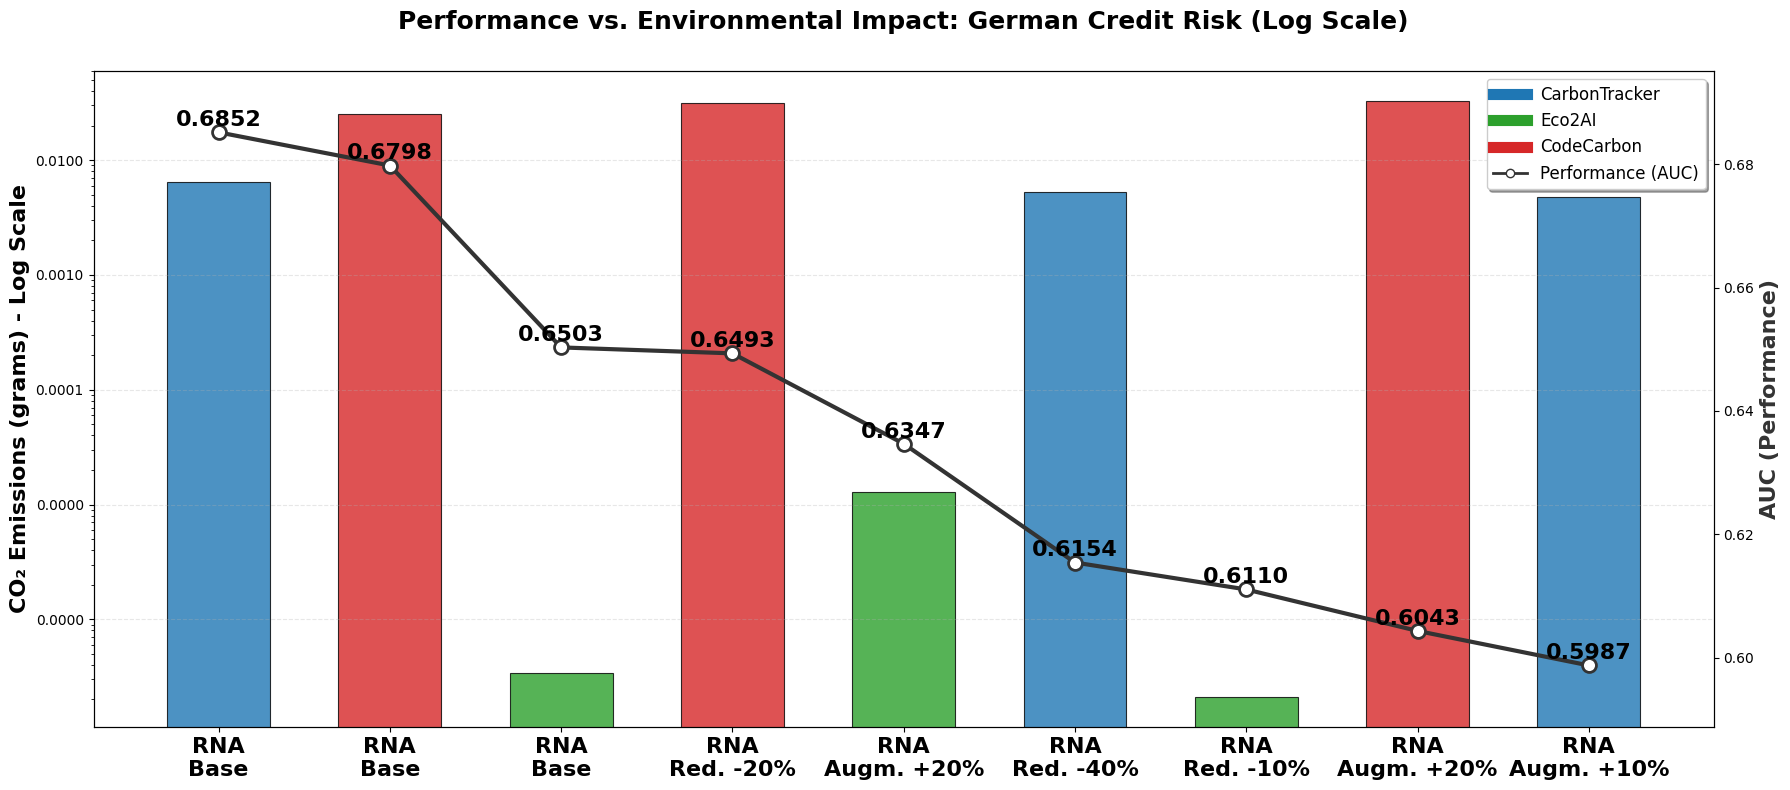

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# 1. Tratamento dos nomes das Estratégias
df_paper = tabela_final.copy()
df_paper['Strategy'] = df_paper['Cenario'].replace({'Aumento': 'Augm.', 'Reducao': 'Red.', 'Raw': 'Base'})
df_paper['Strategy'] = df_paper['Strategy'] + " " + df_paper['Reducao'].fillna('').astype(str) + df_paper['Aumento'].fillna('').astype(str)
df_paper['Strategy'] = df_paper['Strategy'].str.replace('-0%', '', regex=False).str.replace('-0%', '', regex=False)
df_paper['Strategy'] = df_paper['Strategy'].str.replace('nan', '').str.strip()

# 2. Preparar e Ordenar Dados por AUC
df_sorted = df_paper.sort_values(by='AUC', ascending=False).copy()
df_sorted['Biblioteca'] = df_sorted['Biblioteca'].astype(str).str.strip()

lib_colors_map = {
    'CarbonTracker': '#1f77b4',
    'Eco2AI': '#2ca02c',
    'CodeCarbon': '#d62728'
}

bar_colors = []
for b in df_sorted['Biblioteca']:
    color = lib_colors_map.get(b)
    if color is None:
        bl = b.lower()
        if 'eco' in bl: color = lib_colors_map['Eco2AI']
        elif 'track' in bl: color = lib_colors_map['CarbonTracker']
        elif 'code' in bl: color = lib_colors_map['CodeCarbon']
        else: color = '#808080'
    bar_colors.append(color)

labels = [f"{m}\n{s}" for m, s in zip(df_sorted['Modelo'], df_sorted['Strategy'])]

x = np.arange(len(labels))
emissions = df_sorted['Emissoes (g)']
auc = df_sorted['AUC']

# 3. Geração do Gráfico
fig, ax1 = plt.subplots(figsize=(18, 8))

# --- EIXO PRIMÁRIO: Emissões (LOGARÍTMICA) ---
ax1.set_yscale('log') # ATIVAÇÃO DO LOG

bars = ax1.bar(x, emissions, width=0.6, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.8)

# Formatação para o eixo log não ficar confuso
ax1.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.yaxis.set_minor_formatter(ticker.NullFormatter())

ax1.set_ylabel('CO₂ Emissions (grams) - Log Scale', fontsize=16, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=16, fontweight='bold', rotation=0)
ax1.set_title('Performance vs. Environmental Impact: German Credit Risk (Log Scale)',
              fontsize=18, fontweight='bold', pad=30)

# --- EIXO SECUNDÁRIO: AUC ---
ax2 = ax1.twinx()
ax2.plot(x, auc, 'o-', color='#333333', label='Performance (AUC)', markersize=10,
         linewidth=3, markerfacecolor='white', markeredgewidth=2)
ax2.set_ylabel('AUC (Performance)', fontsize=16, color='#333333', fontweight='bold')

# Ajuste da escala da AUC
ax2.set_ylim(min(auc) - 0.01, max(auc) + 0.01)

# Valores de AUC sobre as bolinhas (Fonte 16 como pedido)
for i, v in enumerate(auc):
    ax2.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=16, fontweight='bold')

# --- LEGENDA ---
legend_elements = [
    Line2D([0], [0], color='#1f77b4', lw=8, label='CarbonTracker'),
    Line2D([0], [0], color='#2ca02c', lw=8, label='Eco2AI'),
    Line2D([0], [0], color='#d62728', lw=8, label='CodeCarbon'),
    Line2D([0], [0], color='#333333', lw=2, marker='o', markerfacecolor='white', label='Performance (AUC)')
]
ax1.legend(handles=legend_elements, loc='upper right', frameon=True, shadow=True, fontsize=12)

# Grid para escala log (precisa habilitar o 'both' para as linhas menores aparecerem se quiser)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3, which='major')

plt.tight_layout()
plt.show()

In [ ]:
maior_AUC = tabela_final.loc[tabela_final['AUC'].idxmax()]
menor_emissions = tabela_final.loc[tabela_final['Emissoes (g)'].idxmin()]

In [ ]:
maior_AUC

,3
Modelo,RNA
Reducao,-0%
N_Features,14
Acuracia,0.7033333333
Precisao,0.7080291971
Recall,0.9556650246
F1-Score,0.8134171908
Brier,0.1993291229
AUC,0.6851861256
Tempo (s),4.0157530308


In [ ]:
menor_emissions

,7
Modelo,RNA
Reducao,-10%
N_Features,13
Acuracia,0.6933333333
Precisao,0.6975088968
Recall,0.9655172414
F1-Score,0.8099173554
Brier,0.2149131146
AUC,0.6110405769
Tempo (s),9.1050519943


### APENDICE

In [ ]:
def generate_full_latex_table(df, library_name):
    # 1. Seleção das colunas
    cols_to_show = [
        'Model', 'Strategy', 'Accuracy', 'Precision', 'Recall',
        'F1-Score', 'Brier', 'AUC', 'Time (s)', 'Emissions (g)', 'Energy (kWh)', 'RGA'
    ]

    # Criamos uma cópia para não estragar o DataFrame original
    df_latex = df[cols_to_show].copy()

    # 2. Convertemos tudo para numérico primeiro (para evitar o erro de String)
    cols_numericas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Brier', 'AUC',
                      'RGA', 'Time (s)', 'Emissions (g)', 'Energy (kWh)']

    for col in cols_numericas:
        df_latex[col] = pd.to_numeric(df_latex[col], errors='coerce')

    # 3. Definição dos formatadores (O segredo está aqui)
    formatters = {
        'Accuracy': '{:.4f}'.format,
        'Precision': '{:.4f}'.format,
        'Recall': '{:.4f}'.format,
        'F1-Score': '{:.4f}'.format,
        'Brier': '{:.4f}'.format,
        'AUC': '{:.4f}'.format,
        'RGA': '{:.2e}'.format,
        'Time (s)': '{:.2f}'.format,
        'Emissions (g)': '{:.2e}'.format, # Notação científica para evitar zeros
        'Energy (kWh)': '{:.2e}'.format   # Notação científica
    }

    # 4. Geração das linhas (sem o cabeçalho do to_latex para você colar no seu template)
    print(f"\n% --- Data Rows for {library_name} ---")
    # Usamos formatters em vez de loops para maior segurança
    latex_output = df_latex.to_latex(index=False, header=False, escape=False,
                                     formatters=formatters, column_format='llcccccccccc')
    print(latex_output)

# Executar
generate_full_latex_table(resultados_finais_CC, "CodeCarbon")
generate_full_latex_table(resultados_finais_eco2ai, "Eco2AI")
generate_full_latex_table(resultados_finais_CT, "CarbonTracker")

NameError: name 'resultados_finais_CC' is not defined

In [ ]:
# 1. Primeiro, garantimos a concatenação
resultados_finais_CC = pd.concat([reducao_codecarbon, aumento_codecarbon], ignore_index=True)
resultados_finais_CC['Reducao'] = resultados_finais_CC['Reducao'].combine_first(resultados_finais_CC['Aumento'])

resultados_finais_CC.drop(columns=['Aumento'], inplace=True)

# 2. Criamos um dicionário com DE -> PARA (Português -> Inglês)
traducoes_colunas = {
    'Modelo': 'Model',
    'Reducao': 'Strategy',
    'N_Features': 'Features', # Ou apenas 'Features'
    'Acuracia': 'Accuracy',
    'Precisao': 'Precision',
    'Tempo (s)': 'Time (s)',
    'Energia (kWh)': 'Energy (kWh)',
    'Emissoes (g)': 'Emissions (g)',
    'RGA': 'RGA'                  # Geralmente mantido como sigla, mas pode ser 'ADR' em inglês
}

# 3. Aplicamos a renomeação global
resultados_finais_CC = resultados_finais_CC.rename(columns=traducoes_colunas)

# 4. (Bônus) Traduzindo o valor '-0%' para 'Baseline' ou 'Raw' dentro da coluna Strategy
resultados_finais_CC['Strategy'] = resultados_finais_CC['Strategy'].replace({'-0%': 'Raw'})
resultados_finais_CC['Emissions (g)'] = resultados_finais_CC['Emissions (g)'].map('{:.2e}'.format)
resultados_finais_CC['Energy (kWh)'] = resultados_finais_CC['Energy (kWh)'].map('{:.2e}'.format)
resultados_finais_CC['RGA'] = resultados_finais_CC['RGA'].map('{:.2e}'.format)

# Visualizar o resultado
print(resultados_finais_CC.columns)
resultados_finais_CC

In [ ]:
resultados_finais_CT = pd.concat([reducao_carbontracker, aumento_carbontracker], ignore_index=True)
resultados_finais_CT.drop(columns=['CPU', 'GPU'], inplace=True)

# 2. Criamos um dicionário com DE -> PARA (Português -> Inglês)
traducoes_colunas = {
    'Modelo': 'Model',
    'Reducao': 'Strategy',
    'N_Features': 'Features', # Ou apenas 'Features'
    'Acuracia': 'Accuracy',
    'Precisao': 'Precision',
    'Tempo (s)': 'Time (s)',
    'Energia (kWh)': 'Energy (kWh)',
    'Emissoes (g)': 'Emissions (g)',
    'RGA': 'RGA'                  # Geralmente mantido como sigla, mas pode ser 'ADR' em inglês
}

# 3. Aplicamos a renomeação global
resultados_finais_CT = resultados_finais_CT.rename(columns=traducoes_colunas)

# 4. (Bônus) Traduzindo o valor '-0%' para 'Baseline' ou 'Raw' dentro da coluna Strategy
resultados_finais_CT['Strategy'] = resultados_finais_CT['Strategy'].replace({'-0%': 'Raw'})
resultados_finais_CT['Emissions (g)'] = resultados_finais_CT['Emissions (g)'].map('{:.2e}'.format)
resultados_finais_CT['Energy (kWh)'] = resultados_finais_CT['Energy (kWh)'].map('{:.2e}'.format)
resultados_finais_CT['RGA'] = resultados_finais_CT['RGA'].map('{:.2e}'.format)

# Visualizar o resultado
print(resultados_finais_CT.columns)
resultados_finais_CT

In [ ]:
# 1. Concatenar e remover colunas desnecessárias
resultados_finais_eco2ai = pd.concat([reducao_eco2ai, aumento_eco2ai], ignore_index=True)
resultados_finais_eco2ai.drop(columns=['CPU', 'GPU'], inplace=True)

resultados_finais_eco2ai['Reducao'] = resultados_finais_eco2ai['Reducao'].combine_first(resultados_finais_eco2ai['Aumento'])

resultados_finais_eco2ai.drop(columns=['Aumento'], inplace=True)

traducoes_colunas = {
    'Modelo': 'Model',
    'Reducao': 'Strategy',
    'N_Features': 'Features', # Ou apenas 'Features'
    'Acuracia': 'Accuracy',
    'Precisao': 'Precision',
    'Tempo (s)': 'Time (s)',
    'Energia (kWh)': 'Energy (kWh)',
    'Emissoes (g)': 'Emissions (g)',
    'RGA': 'RGA'                  # Geralmente mantido como sigla, mas pode ser 'ADR' em inglês
}

# 3. Aplicamos a renomeação global
resultados_finais_eco2ai = resultados_finais_eco2ai.rename(columns=traducoes_colunas)

# 4. (Bônus) Traduzindo o valor '-0%' para 'Baseline' ou 'Raw' dentro da coluna Strategy
resultados_finais_eco2ai['Strategy'] = resultados_finais_eco2ai['Strategy'].replace({'-0%': 'Raw'})
resultados_finais_eco2ai['Emissions (g)'] = resultados_finais_eco2ai['Emissions (g)'].map('{:.2e}'.format)
resultados_finais_eco2ai['Energy (kWh)'] = resultados_finais_eco2ai['Energy (kWh)'].map('{:.2e}'.format)
resultados_finais_eco2ai['RGA'] = resultados_finais_eco2ai['RGA'].map('{:.2e}'.format)

print(resultados_finais_eco2ai.columns)
resultados_finais_eco2ai

In [ ]:
import pandas as pd

# Lista dos seus dataframes
dfs = [resultados_finais_eco2ai, resultados_finais_CC, resultados_finais_CT]

total_co2 = 0
total_energia = 0

for df in dfs:
    # Ajuste o nome da coluna aqui para o que está no seu DF (Emissoes ou Emissions)
    # pd.to_numeric converte textos em números; errors='coerce' vira NaN se for lixo, e .sum() ignora NaN
    total_co2 += pd.to_numeric(df['Emissions (g)'], errors='coerce').sum()
    total_energia += pd.to_numeric(df['Energy (kWh)'], errors='coerce').sum()

# Analogia
km_equivalente = total_co2 / 120

print(f"--- RESULTADOS CONSOLIDADOS (CORRIGIDOS) ---")
print(f"Total de CO2 emitido: {total_co2:.4f} g")
print(f"Total de Energia consumida: {total_energia:.6f} kWh")
print(f"Equivalente a {km_equivalente:.4f} km de um carro.")